Analysis of different features affecting community hiding (measured with M1 and M2)


In [206]:
import os
import glob
import pandas as pd
# This script combines multiple CSV files into a single DataFrame.
# csv_files = glob.glob("full_bigred200_*.csv")
folder = 'results'
csv_files = glob.glob(os.path.join(folder, "dmon_dice_*.csv"))
# csv_files = glob.glob("full_bigred200_*min_com10.csv")

# Combine all CSVs into one DataFrame
df_list = [pd.read_csv(file) for file in csv_files]
results_df = pd.concat(df_list, ignore_index=True)

print(f'Total rows/columns: {results_df.shape}') 



Total rows/columns: (2112510, 11)


In [207]:
results_df

,mu,sigma_c,target_label,target_size,b,b_percentage,realization,ECS,M1,M2,elapsed_time_sec
0,0.1,0.01,0,20,0,0.00,0,0.511970,0.004630,0.135714,NaN
1,0.1,0.01,0,20,1,0.01,1,0.447111,0.008333,0.090816,1.458132
2,0.1,0.01,0,20,1,0.01,2,0.405521,0.004902,0.132653,1.403906
3,0.1,0.01,0,20,1,0.01,3,0.388527,0.005208,0.146939,1.422796
4,0.1,0.01,0,20,1,0.01,4,0.405203,0.004902,0.097959,1.384152
...,...,...,...,...,...,...,...,...,...,...,...
2112505,0.5,5.00,24,37,259,1.00,46,0.343042,0.097222,0.526480,1.321575
2112506,0.5,5.00,24,37,259,1.00,47,0.347410,0.133333,0.674974,1.297099
2112507,0.5,5.00,24,37,259,1.00,48,0.417641,0.071429,0.497404,1.297144
2112508,0.5,5.00,24,37,259,1.00,49,0.379320,0.030556,0.462098,1.282798


In [208]:
import community_features as cf
import pandas as pd
folder = "results_graphs/"
all_feature_dfs = []
# for edgelist_file in glob.glob(os.path.join(folder, "*min_comm10.edgelist")):
#     membership_file = edgelist_file.replace('min_comm10.edgelist', 'min_comm10.membership')
for edgelist_file in glob.glob(os.path.join(folder, "*.edgelist")):
    membership_file = edgelist_file.replace('.edgelist', '.membership')
    # print(f'Processing {edgelist_file} with membership {membership_file}')
    G, membership = cf.load_graph_with_membership(edgelist_file, membership_file)
    print(f'Loaded graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges')
    features_df = cf.extract_community_features(G, membership)
    # Extract mu, sigma_c, min_comm from filename for merge
    print(f'Extrancting n {edgelist_file.split('_')[2][1:]}, mu {edgelist_file.split("_")[3][2:]}, sigma_c {edgelist_file.split("_")[4][5:]}, min_comm {edgelist_file.split("_")[6][4:6]}')
    n = int(edgelist_file.split('_')[2][1:])  # Extracting the number of nodes from the filename
    mu = float(edgelist_file.split('_')[3][2:])  # Extracting mu from the filename
    sigma_c = float(edgelist_file.split('_')[4][5:])  # Extracting sigma_c from the filename
    min_comm = int(edgelist_file.split('_')[6][4:6])  # Extracting min_comm from the filename
    features_df['mu'] = mu
    features_df['sigma_c'] = sigma_c
    features_df['min_comm'] = min_comm
    all_feature_dfs.append(features_df)
all_features_df = pd.concat(all_feature_dfs, ignore_index=True)

# average the results_df by target_label, mu, sigma_c over all budgets and realizations

agg_df = (
    results_df
    .groupby(['mu', 'sigma_c', 'target_label', 'target_size'], as_index=False)
    .agg({
        'M1': 'mean',
        'M2': 'mean',
        'ECS': 'mean'
    })
)

full_df = pd.merge(agg_df, all_features_df, on=['target_label', 'mu', 'sigma_c'], how='left')


Loaded graph with 1000 nodes and 17234 edges
Extrancting n 1000, mu 0.01, sigma_c 1.0, min_comm 60
Loaded graph with 1000 nodes and 17022 edges
Extrancting n 1000, mu 0.01, sigma_c 2, min_comm 10
Loaded graph with 1000 nodes and 18039 edges
Extrancting n 1000, mu 0.2, sigma_c 0.5, min_comm 30
Loaded graph with 1000 nodes and 17448 edges
Extrancting n 1000, mu 0.1, sigma_c 2, min_comm 10
Loaded graph with 1000 nodes and 18510 edges
Extrancting n 1000, mu 0.4, sigma_c 5.0, min_comm 10
Loaded graph with 1000 nodes and 18839 edges
Extrancting n 1000, mu 0.5, sigma_c 2.0, min_comm 10
Loaded graph with 1000 nodes and 18839 edges
Extrancting n 1000, mu 0.5, sigma_c 0.5, min_comm 10
Loaded graph with 1000 nodes and 18504 edges
Extrancting n 1000, mu 0.3, sigma_c 0.5, min_comm 60
Loaded graph with 1000 nodes and 18414 edges
Extrancting n 1000, mu 0.3, sigma_c 5.0, min_comm 30
Loaded graph with 1000 nodes and 17448 edges
Extrancting n 1000, mu 0.1, sigma_c 1.0, min_comm 10
Loaded graph with 1000

In [209]:
full_df

,mu,sigma_c,target_label,target_size,M1,M2,ECS,community_size,intra_edges,inter_edges,...,betweenness_mean,betweenness_std,betweenness_median,closeness_mean,closeness_std,closeness_median,eigenvector_mean,eigenvector_std,eigenvector_median,min_comm
0,0.01,0.01,0,15,0.012358,0.107325,0.660053,100,3089,46,...,0.004948,0.008724,0.000131,0.318593,0.009659,0.317044,0.096572,0.025919,9.375061e-02,30
1,0.01,0.01,0,15,0.012358,0.107325,0.660053,15,97,3,...,0.001562,0.003145,0.000002,0.195834,0.016738,0.187472,0.000004,0.000006,8.952631e-07,10
2,0.01,0.01,0,15,0.012358,0.107325,0.660053,89,1528,25,...,0.002262,0.004270,0.000122,0.280342,0.012668,0.277192,0.000625,0.000562,4.736379e-04,60
3,0.01,0.01,0,89,0.013220,0.544720,0.731955,100,3089,46,...,0.004948,0.008724,0.000131,0.318593,0.009659,0.317044,0.096572,0.025919,9.375061e-02,30
4,0.01,0.01,0,89,0.013220,0.544720,0.731955,15,97,3,...,0.001562,0.003145,0.000002,0.195834,0.016738,0.187472,0.000004,0.000006,8.952631e-07,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5809,0.50,5.00,20,14,0.045342,0.221345,0.376121,14,68,331,...,0.000794,0.000233,0.000817,0.445475,0.013951,0.451016,0.023034,0.004384,2.467072e-02,10
5810,0.50,5.00,21,13,0.036827,0.200601,0.375294,13,53,293,...,0.000692,0.000187,0.000701,0.441126,0.014883,0.443016,0.021170,0.004435,2.112696e-02,10
5811,0.50,5.00,22,100,0.023345,0.665010,0.359556,100,738,2760,...,0.001598,0.001815,0.000666,0.464883,0.027177,0.460264,0.033152,0.014832,2.762785e-02,10
5812,0.50,5.00,23,45,0.005340,0.146811,0.365825,45,406,1220,...,0.001485,0.001435,0.000825,0.466658,0.021070,0.463358,0.036440,0.012789,3.199826e-02,10


## Linear Regression
Trying to simple regression, testing the assumptions first. Turns out for community/node-based features the assumption of error normality and homoscedacity fails. 

In [174]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = full_df[['community_size', 'inter_intra_ratio', 
                      'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 
                      'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 
                      'mu', 'sigma_c', 'min_comm']]
X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'comm_closeness', 'sigma_c']]
X_node_level = full_df[['degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 'sigma_c']]
# X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'sigma_c']]
X = X_comm_level
m1 = full_df['M1']  
m2 = full_df['M2'] 
ecs = full_df['ECS']

X_train, X_test, y_train, y_test = train_test_split(X, m1, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
linreg = LinearRegression()
linreg.fit(X_train, y_train)
for feature, coef in zip(X.columns, linreg.coef_):
    print(f"{feature}: {coef:.4f}")
print("Linear Regression Test R^2:", linreg.score(X_test, y_test))


community_size: 0.0001
inter_intra_ratio: 0.0180
comm_betweenness: 0.0009
comm_closeness: -0.0055
sigma_c: -0.0099
Linear Regression Test R^2: 0.3765164648585043


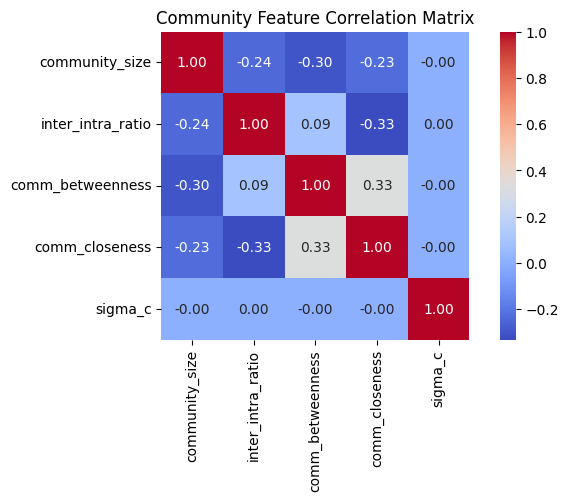

In [175]:
# plot feature covariance matrix
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = full_df[['community_size', 'inter_intra_ratio', 
                      'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 
                      'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 
                      'mu', 'sigma_c', 'M1', 'M2', 'ECS']].corr()
# print("Feature Correlation Matrix:")
# print(corr_matrix)
comm_corr_matrix = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'comm_closeness', 'sigma_c']].corr()
# comm_corr_matrix = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness','sigma_c']].corr()
# comm_corr_matrix = full_df[['degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 'sigma_c']].corr()

plt.figure(figsize=(8, 4))
sns.heatmap(comm_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True )
plt.title("Community Feature Correlation Matrix")
plt.show()

In [176]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
for col, v in zip(X.columns, vif):
    print(f"{col}: VIF={v:.2f}")
# VIF > 5 (some say 10) indicates multicollinearity problem


community_size: VIF=1.95
inter_intra_ratio: VIF=1.40
comm_betweenness: VIF=1.43
comm_closeness: VIF=1.78
sigma_c: VIF=1.59


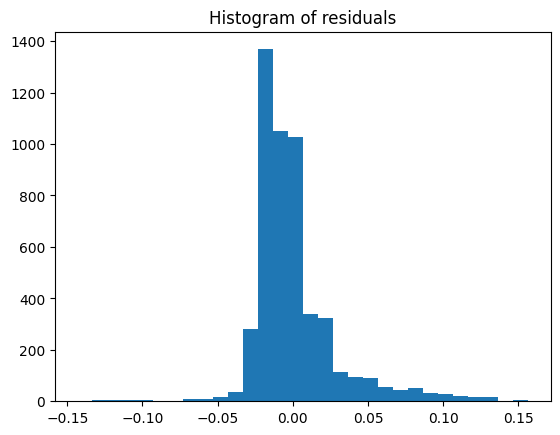

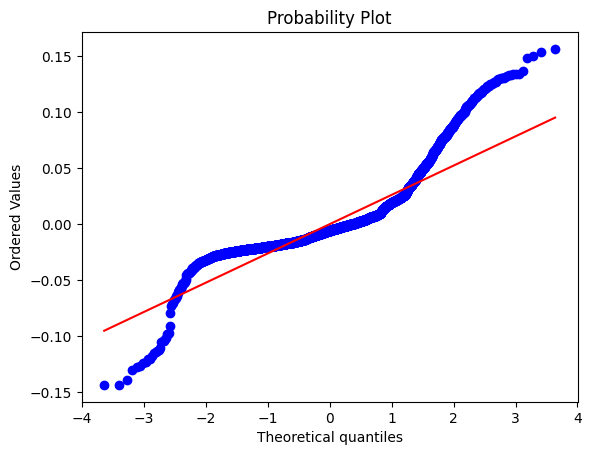

Shapiro-Wilk p-value: 3.7572796640294984e-60
Kolmogorov-Smirnov p-value: 2.4840224792233787e-127


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5058.
  res = hypotest_fun_out(*samples, **kwds)


In [177]:
import scipy.stats as stats

residuals = m1 - linreg.predict(X_scaled)

# Histogram
plt.hist(residuals, bins=30)
plt.title("Histogram of residuals")
plt.show()

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

# Shapiro-Wilk test
print("Shapiro-Wilk p-value:", stats.shapiro(residuals)[1])
# p > 0.05 means residuals are likely normal

# Kolmogorov-Smirnov test
ks_stat, ks_p_value = stats.kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
print("Kolmogorov-Smirnov p-value:", ks_p_value)
# p > 0.05 means residuals are likely normal

In [178]:
from statsmodels.stats.stattools import durbin_watson
print("Durbin-Watson:", durbin_watson(residuals))
# Value ~2 is good; <1 or >3 means possible autocorrelation


Durbin-Watson: 0.8114024106411575


In [ ]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Add constant to X for statsmodels
X_const = sm.add_constant(X)
model = sm.OLS(m1, X_const).fit()
bp_test = het_breuschpagan(model.resid, model.model.exog)
print("Breusch-Pagan test p-value:", bp_test[1])
# p < 0.05 means heteroscedasticity is present (Unequal Variance of Errors)


Breusch-Pagan test p-value: 2.048984944920784e-219


## Random Forest Regression and Shapley Values

______________________

Running Random Forest Regression (for simplicity) then analysis of feature importance (GINI-based and Shap). Feature importance is performed to analyze the effect of certain features on M1 and M2.

In [210]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = full_df[['community_size', 'inter_intra_ratio', 
                      'comm_degree_centrality', 'comm_betweenness', 'comm_closeness', 
                      'degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean',  'sigma_c']]

# X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'comm_closeness', 'sigma_c', 'min_comm']]
# X_node_level = full_df[['degree_centrality_mean', 'betweenness_mean', 'closeness_mean', 'eigenvector_mean', 'sigma_c', 'min_comm']]
# X_comm_level = full_df[['community_size', 'inter_intra_ratio', 'comm_betweenness', 'sigma_c']]
# X = X_node_level

m1 = full_df['M1']  
m2 = full_df['M2'] 
ecs = full_df['ECS']

X_train_m1, X_test, y_train, y_test = train_test_split(X, m1, test_size=0.2, random_state=42)

m1_reg = RandomForestRegressor(n_estimators=100, random_state=42)
m1_reg.fit(X_train_m1, y_train)
# sort the feature importances
feature_importances = dict(zip(X.columns, m1_reg.feature_importances_))
feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))


print("Test R^2:", m1_reg.score(X_test, y_test))
print("Feature importances for M1:")
for feature, importance in feature_importances.items():
    print(f"{feature}: {importance:.4f}")


Test R^2: 0.6160065165253843
Feature importances for M1:
inter_intra_ratio: 0.5533
sigma_c: 0.3028
closeness_mean: 0.0318
comm_closeness: 0.0249
community_size: 0.0245
betweenness_mean: 0.0199
degree_centrality_mean: 0.0181
eigenvector_mean: 0.0155
comm_betweenness: 0.0082
comm_degree_centrality: 0.0011


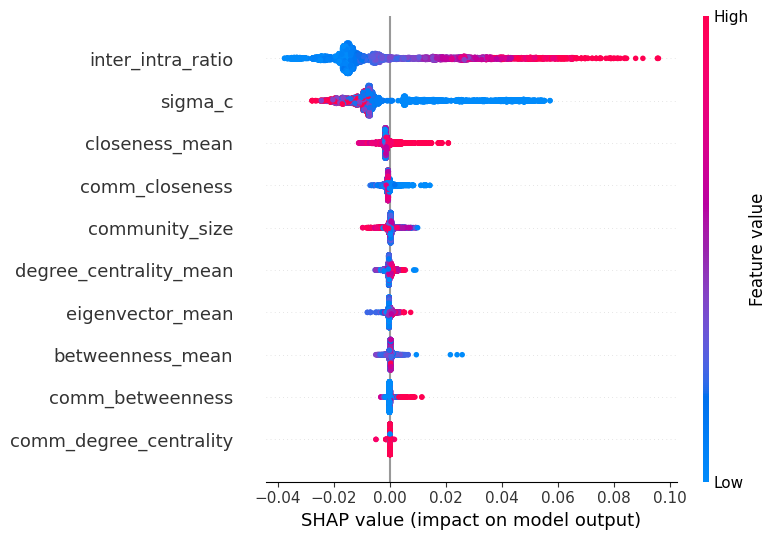

In [211]:
import shap
import matplotlib.pyplot as plt

# Create an explainer for the RandomForestRegressor
explainer = shap.TreeExplainer(m1_reg)

# Calculate SHAP values for the training dataset
shap_values_m1 = explainer.shap_values(X_train_m1)
features = X_train_m1.columns.tolist()

shap.summary_plot(shap_values_m1, X_train_m1, feature_names=features)
plt.show()

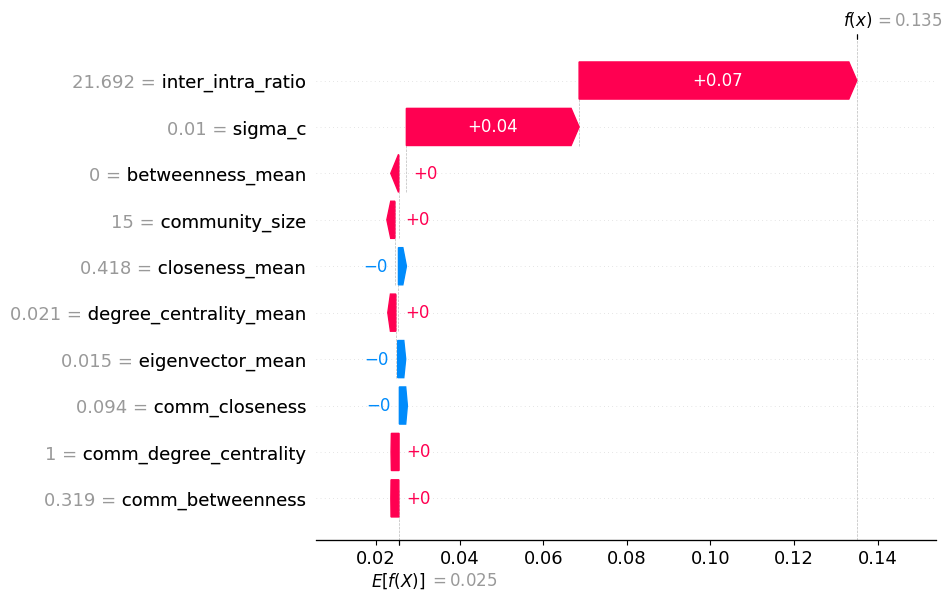

In [213]:
# For waterfall plot: select ONE sample
sample_idx = 10  # or any index you want
sample_shap_values = shap_values_m1[sample_idx]
sample_features = X_train_m1.iloc[sample_idx]

# Waterfall plot (for a single sample)
shap.plots.waterfall(shap.Explanation(values=sample_shap_values, 
                                      base_values=explainer.expected_value, 
                                      data=sample_features, 
                                      feature_names=features))
plt.show()

In [134]:
# import shap
# import matplotlib.pyplot as plt
# feature_index = 1  # Change this to the index of the feature you want to plot

# shap.dependence_plot(feature_index, shap_values, X_train, feature_names=features)
# plt.show()

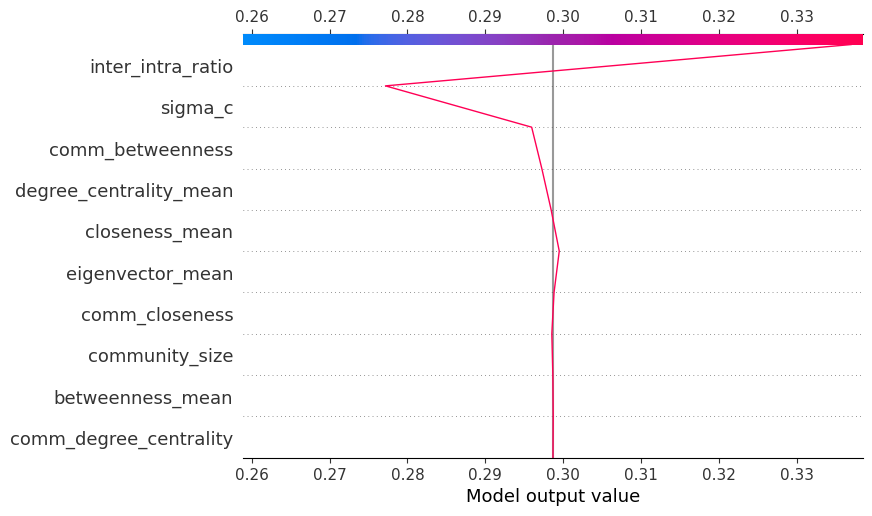

In [217]:
import shap
import matplotlib.pyplot as plt

# Assuming 'explainer' and 'shap_values' are available
shap.decision_plot(explainer.expected_value[0], shap_values_m1[0], feature_names=features)
plt.show()

In [135]:
# import shap
# import matplotlib.pyplot as plt

# features = X_train.columns.tolist()

# shap.summary_plot(shap_values, X_train, feature_names=features, plot_type="bar")
# plt.show()

In [214]:
X_train_m2, X_test, y_train, y_test = train_test_split(X, m2, test_size=0.2, random_state=42)

m2_reg = RandomForestRegressor(n_estimators=100, random_state=42)
m2_reg.fit(X_train_m2, y_train)
# sort the feature importances
feature_importances = dict(zip(X.columns, m2_reg.feature_importances_))
feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))


print("Test R^2:", m2_reg.score(X_test, y_test))
# Built-in feature importance (Gini Importance)
print("Feature importances for M2:")
for feature, importance in feature_importances.items():
    print(f"{feature}: {importance:.4f}")

Test R^2: 0.7057437816773335
Feature importances for M2:
inter_intra_ratio: 0.5734
sigma_c: 0.2603
closeness_mean: 0.0756
comm_closeness: 0.0316
community_size: 0.0165
eigenvector_mean: 0.0130
betweenness_mean: 0.0129
degree_centrality_mean: 0.0109
comm_betweenness: 0.0048
comm_degree_centrality: 0.0010


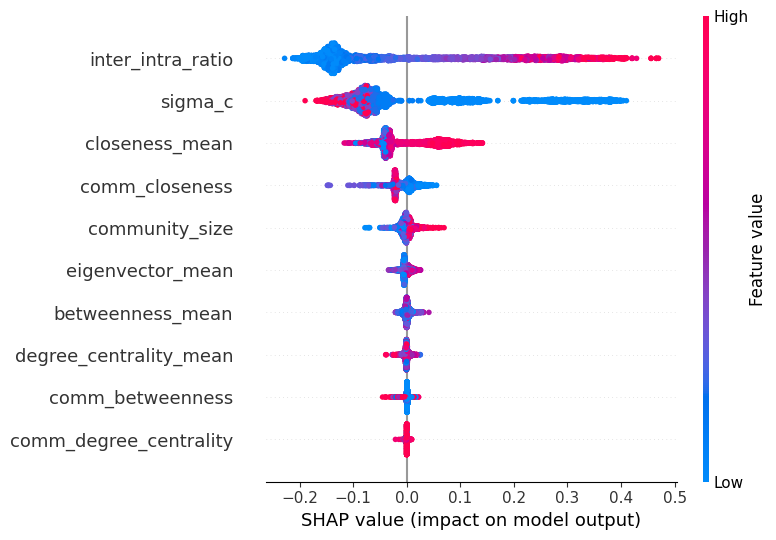

In [215]:
import shap

# Create an explainer for the RandomForestRegressor
explainer = shap.TreeExplainer(m2_reg)

# Calculate SHAP values for the training dataset
shap_values_m2 = explainer.shap_values(X_train_m2)

features = X_train_m2.columns.tolist()

shap.summary_plot(shap_values_m2, X_train_m2, feature_names=features)
plt.show()

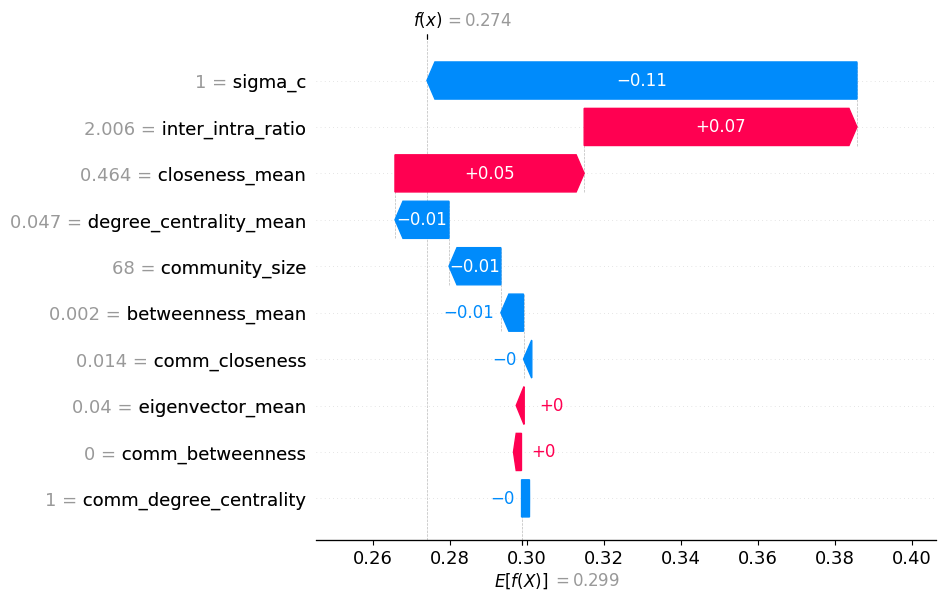

In [216]:
# For waterfall plot: select ONE sample
sample_idx = 5  # or any index you want
sample_shap_values = shap_values_m2[sample_idx]
sample_features = X_train_m2.iloc[sample_idx]

# Waterfall plot (for a single sample)
shap.plots.waterfall(shap.Explanation(values=sample_shap_values, 
                                      base_values=explainer.expected_value, 
                                      data=sample_features, 
                                      feature_names=features))
plt.show()

In [188]:
X_train, X_test, y_train, y_test = train_test_split(X, ecs, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_train)
# sort the feature importances
feature_importances = dict(zip(X.columns, reg.feature_importances_))
feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))


print("Test R^2:", reg.score(X_test, y_test))
print("Feature importances for ECS:")
for feature, importance in feature_importances.items():
    print(f"{feature}: {importance:.4f}")

Test R^2: 0.962673814424942
Feature importances for ECS:
inter_intra_ratio: 0.5563
sigma_c: 0.3535
closeness_mean: 0.0641
comm_closeness: 0.0103
eigenvector_mean: 0.0058
degree_centrality_mean: 0.0036
betweenness_mean: 0.0027
community_size: 0.0019
comm_betweenness: 0.0015
comm_degree_centrality: 0.0004


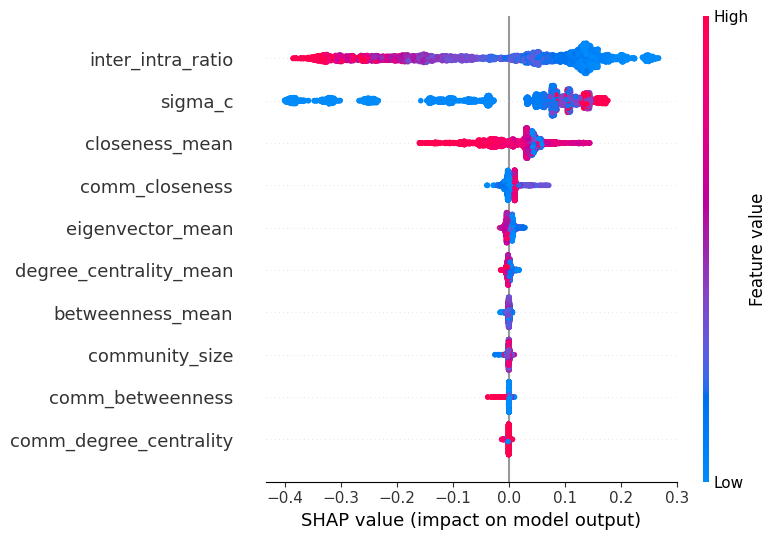

In [189]:
import shap

# Create an explainer for the RandomForestRegressor
explainer = shap.TreeExplainer(reg)

# Calculate SHAP values for the training dataset
shap_values = explainer.shap_values(X_train)

features = X_train.columns.tolist()

shap.summary_plot(shap_values, X_train, feature_names=features)
plt.show()